In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBClassifier

In [3]:
# 1. Load Data & Drop useless columns (Assuming RFM scores are already calculated here)
df = pd.read_csv('E_Commerce_Dataset.csv')
df = df.drop(columns=['CustomerID']) # Keep everything else raw!

In [4]:
df

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,151
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186
5628,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,179


## Exploratory Data Analysis

In [5]:
df.isnull().sum()

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [6]:
df.describe()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


In [7]:
df.dtypes

Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object

In [8]:
df['PreferredPaymentMode'].unique()

array(['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD',
       'Credit Card'], dtype=object)

In [9]:
for col in df.columns:
    print(col, ":", df[col].unique())
    print()

Churn : [1 0]

Tenure : [ 4. nan  0. 13. 11.  9. 19. 20. 14.  8. 18.  5.  2. 30.  1. 23.  3. 29.
  6. 26. 28.  7. 24. 25. 10. 15. 22. 27. 16. 12. 21. 17. 50. 60. 31. 51.
 61.]

PreferredLoginDevice : ['Mobile Phone' 'Phone' 'Computer']

CityTier : [3 1 2]

WarehouseToHome : [  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  nan  10.  27.  17.  23.  33.  19.  35.  24.  16.  25.  32.
  34.   5.  21. 126.   7.  36. 127.]

PreferredPaymentMode : ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender : ['Female' 'Male']

HourSpendOnApp : [ 3.  2. nan  1.  0.  4.  5.]

NumberOfDeviceRegistered : [3 4 5 2 1 6]

PreferedOrderCat : ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

SatisfactionScore : [2 3 5 4 1]

MaritalStatus : ['Single' 'Divorced' 'Married']

NumberOfAddress : [ 9  7  6  8  3  2  4 10  1  5 19 21 11 20 22]

Complain : [1 0]

OrderAmountHikeFromlastYear : [11. 15. 14. 23. 22. 16. 12. nan 13

In [10]:
df.select_dtypes(include ='object').columns

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

In [11]:
df['Churn'].value_counts(normalize = True)*100

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

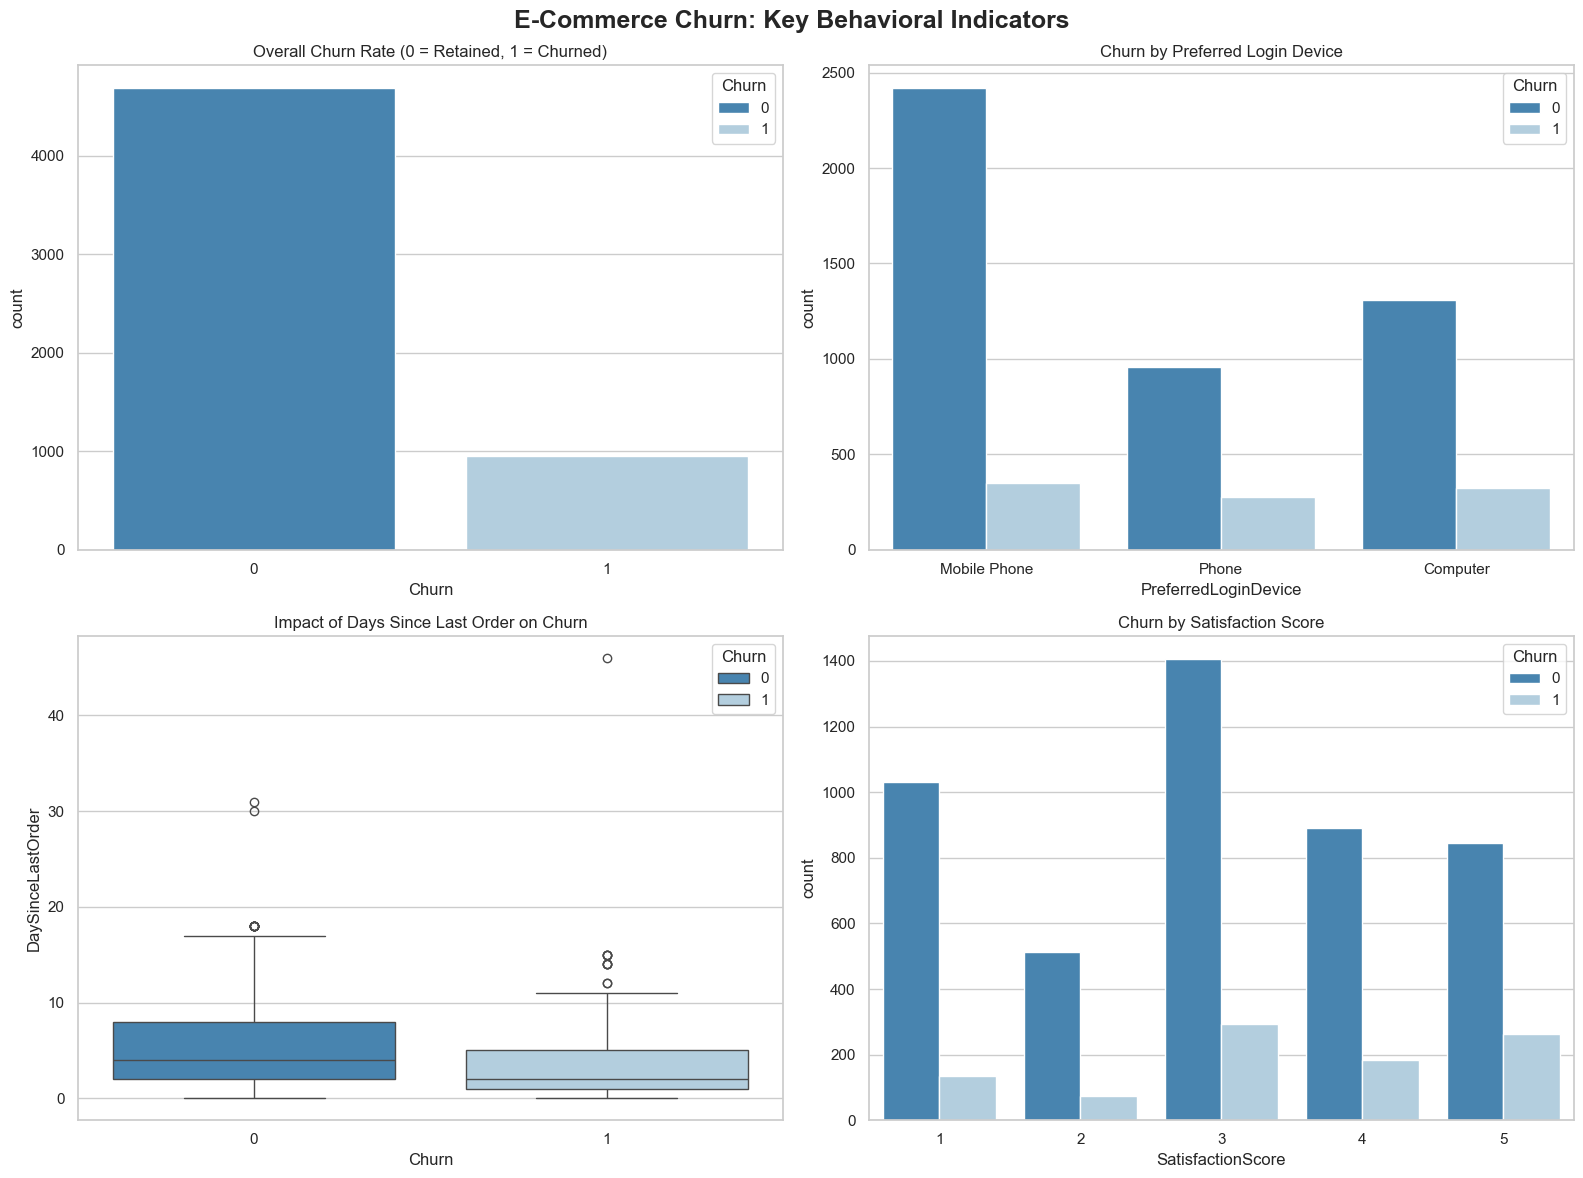

In [12]:
# Setup
sns.set_theme(style="whitegrid") 

# Create a 2x2 grid for our portfolio visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Churn: Key Behavioral Indicators', fontsize=18, fontweight='bold')

# Plot A: The Target Variable (Checking for imbalanced data)
sns.countplot(data=df, x='Churn',hue='Churn', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Overall Churn Rate (0 = Retained, 1 = Churned)')

# Plot B: Categorical vs Target (Are mobile users leaving faster?)
sns.countplot(data=df, x='PreferredLoginDevice', hue='Churn', ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('Churn by Preferred Login Device')

# Plot C: Numeric vs Target (Do churning users stop ordering early?)
sns.boxplot(data=df, x='Churn',hue='Churn', y='DaySinceLastOrder', ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Impact of Days Since Last Order on Churn')

# Plot D: Numeric vs Target (Does a bad score actually mean they leave?)
sns.countplot(data=df, x='SatisfactionScore', hue='Churn', ax=axes[1, 1], palette='Blues_r')
axes[1, 1].set_title('Churn by Satisfaction Score')

plt.tight_layout()
plt.show()

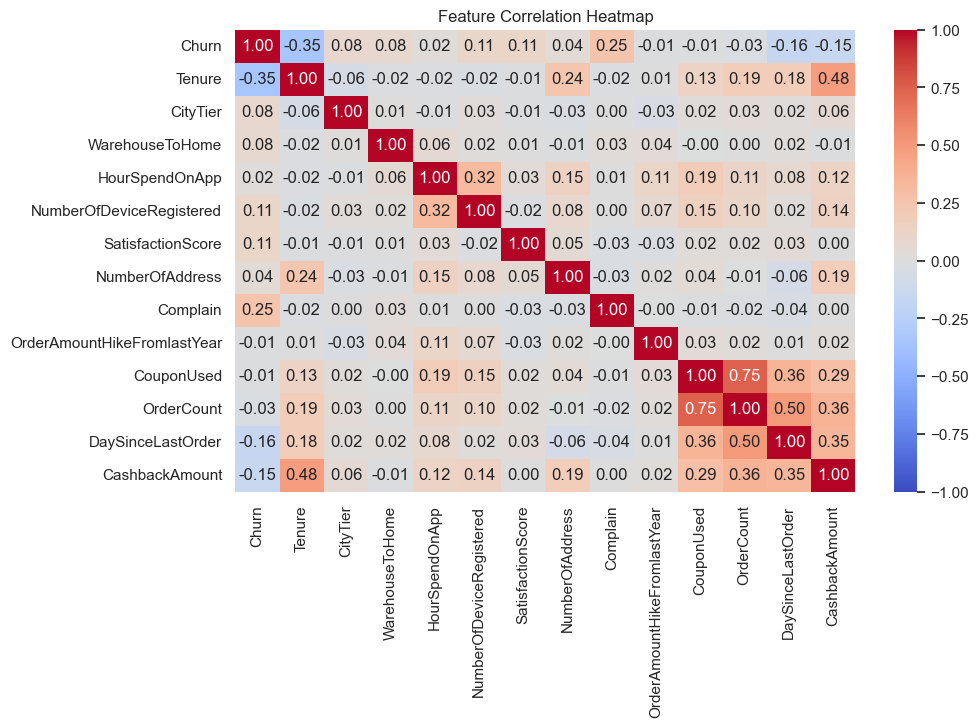

In [13]:
# Correlation Heatmap (Finding hidden relationships)
plt.figure(figsize=(10, 6))
# Grab only numeric columns and drop CustomerID if it's there
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['CustomerID'], errors='ignore')

# Plot the matrix
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

## PreProcessing

In [14]:
# Engineer RFM Scores using pd.qcut (Quantile-based discretization)

df['R_Score'] = pd.qcut(df['DaySinceLastOrder'], q=4, labels=[1,2,3,4])

# Note: duplicates='drop' is used in case many customers have the exact same low order count
# Create the bins, drop duplicates, and automatically assign labels (1, 2, 3...)
df['F_Score'] = pd.qcut(df['OrderCount'], q=4, duplicates='drop').cat.codes + 1

# For Monetary: Higher cashback means higher spend, which is BETTER
df['M_Score'] = pd.qcut(df['CashbackAmount'], q=4, labels=[1, 2, 3, 4])

# Combine into a single RFM Segment or total score
# Note on F_Score: .cat.codes assigns -1 to missing values. Adding 1 makes them 0.
# We replace 0 with np.nan so our pipeline's Imputer can handle it correctly!
df['F_Score'] = df['F_Score'].replace(0, np.nan)

# Convert scores to FLOAT instead of INT so they can handle NaNs without crashing
df['R_Score'] = df['R_Score'].astype(float)
df['F_Score'] = df['F_Score'].astype(float)
df['M_Score'] = df['M_Score'].astype(float)

# Create a total RFM score (Missing values here will also become NaN, which is perfect for your imputer)
df['RFM_Total_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']

# Optional: Segment customers based on the total score
def segment_customer(score):
    if pd.isna(score):
        return 'Unknown' # Handle missing scores safely
    elif score >= 10:
        return 'VIP'
    elif score >= 7:
        return 'Loyal'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

df['Customer_Segment'] = df['RFM_Total_Score'].apply(segment_customer)

In [15]:
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery',
    'E wallet': 'E-Wallet'
})

In [16]:
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({
    'Phone': 'Mobile Phone'
})

In [17]:
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({
    'Mobile': 'Mobile Phone'
})

In [18]:
df.head(2)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,...,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,R_Score,F_Score,M_Score,RFM_Total_Score,Customer_Segment
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,...,11.0,1.0,1.0,5.0,160,3.0,1.0,2.0,6.0,At Risk
1,1,NaN,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,...,15.0,0.0,1.0,0.0,121,1.0,1.0,1.0,3.0,Lost


In [19]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
numeric_features = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
                    'OrderAmountHikeFromlastYear', 'CouponUsed', 
                    'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'] 

categorical_features = ['PreferredLoginDevice', 'PreferredPaymentMode', 
                        'Gender', 'PreferedOrderCat', 'MaritalStatus']



In [21]:
# Create Transformers (The instructions for how to handle each type of data)
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()) # Scaling helps models perform better!
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Handles new categories gracefully
])

# Combine into a Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])



In [22]:
smote = SMOTE(random_state=42 )

xgb_pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),   # First: Impute and Encode (keeps data clean)
    ('smote', smote),                 # Second: Generate synthetic Churners
    # use_label_encoder=False and eval_metric='logloss' prevent annoying deprecation warnings
    ('clf', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')) # Third: Train
])

# Train the model
xgb_pipeline_smote.fit(X_train, y_train)

c:\Users\mohit\Desktop\ecommerce_churn_project\churn_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:02:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [23]:
# Define the metrics we want to track during Cross-Validation
scoring_metrics = ['accuracy', 'f1', 'roc_auc', 'recall']

param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__max_depth': [3, 5, 7],
    'clf__min_child_weight': [1, 3, 5],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    xgb_pipeline_smote,
    param_distributions= param_grid,
    n_iter=40,  # Randomly tries 40 combinations from the grid
    cv=5,
    scoring=scoring_metrics,
    refit='recall',  # <--- Tells the grid to use recall to pick the absolute best model
    n_jobs=-1 
)

# Fit the model
random_search.fit(X_train, y_train)

# This will now print the best MEAN F1 SCORE from the cross-validation
print(f"Mean Recall Score: {random_search.best_score_:.4f}")

c:\Users\mohit\Desktop\ecommerce_churn_project\churn_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:05:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mean Recall Score: 0.7389


In [39]:
# Get the index of the winning hyperparameter combination
best_index = random_search.best_index_

# Extract the mean scores for that specific index
best_cv_recall = random_search.cv_results_['mean_test_recall'][best_index]
best_cv_f1 = random_search.cv_results_['mean_test_f1'][best_index]
best_cv_roc_auc = random_search.cv_results_['mean_test_roc_auc'][best_index]
best_cv_accuracy = random_search.cv_results_['mean_test_accuracy'][best_index]

# 3. Print them neatly
print("--- Mean CV Scores for the WINNING Model ---")
print(f"Recall:   {best_cv_recall:.4f}<-- (This matches grid.best_score_)")
print(f"F1-Score: {best_cv_f1:.4f}")
print(f"ROC-AUC:  {best_cv_roc_auc:.4f}")
print(f"Accuracy: {best_cv_accuracy:.4f}")

--- Mean CV Scores for the WINNING Model ---
Recall:   0.7389<-- (This matches grid.best_score_)
F1-Score: 0.7722
ROC-AUC:  0.9475
Accuracy: 0.9267


In [25]:
best_recall_folds = [random_search.cv_results_[f'split{i}_test_recall'][best_index] for i in range(5)]

print("Recall score across folds for best model:", best_recall_folds)

Recall score across folds for best model: [np.float64(0.7483443708609272), np.float64(0.75), np.float64(0.7368421052631579), np.float64(0.6710526315789473), np.float64(0.7880794701986755)]


In [26]:
print("Best params:", random_search.best_params_)

Best params: {'clf__subsample': 0.8, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 7, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.8}


In [27]:
# 5. EVALUATE without threshold
y_pred = xgb_pipeline_smote.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       936
           1       0.90      0.79      0.84       190

    accuracy                           0.95      1126
   macro avg       0.93      0.89      0.91      1126
weighted avg       0.95      0.95      0.95      1126

[[919  17]
 [ 40 150]]


In [28]:
# The probability of Churn (Class 1)
y_pred_probs = random_search.predict_proba(X_test)[:,1]

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)

# Compute F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find best threshold
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_index])

Best Threshold: 0.34302863
Best F1 Score: 0.8675324675324675


In [29]:
# Setting a custom threshold / best_threshold
y_pred_custom = (y_pred_probs >= best_threshold).astype(int)

# Check the new confusion matrix and classification report
from sklearn.metrics import classification_report, confusion_matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

Accuracy: 0.9547
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       936
           1       0.86      0.88      0.87       190

    accuracy                           0.95      1126
   macro avg       0.92      0.92      0.92      1126
weighted avg       0.96      0.95      0.95      1126

[[908  28]
 [ 23 167]]


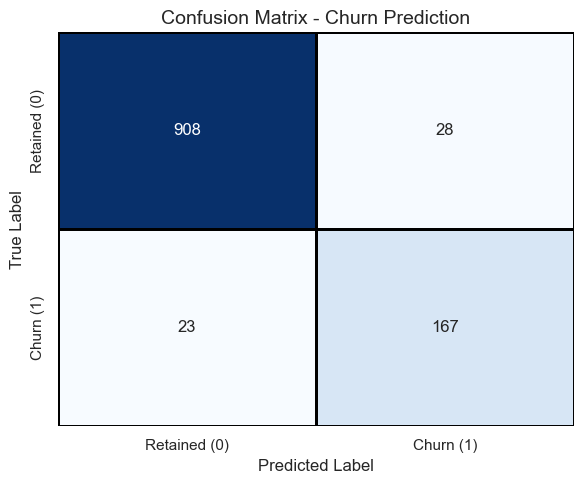

In [30]:
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='black',
    xticklabels=['Retained (0)', 'Churn (1)'],
    yticklabels=['Retained (0)', 'Churn (1)']
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Churn Prediction", fontsize=14)

plt.tight_layout()
plt.show()

In [31]:

joblib.dump(xgb_pipeline_smote, 'xgb_churn_pipeline.pkl')
print("Pipeline saved!")

Pipeline saved!


## SHAP

In [32]:
# Extract the best XGBoost pipeline from your fitted grid
best_pipeline = random_search.best_estimator_

# Extract the trained XGBoost classifier from that pipeline (using 'clf')
xgb_model = best_pipeline.named_steps['clf']

# Extract the preprocessor step (your ColumnTransformer)
preprocessor = best_pipeline.named_steps['preprocessor']

# Get the feature names after transformations (like One-Hot Encoding)
feature_names = preprocessor.get_feature_names_out()

# Transform the test data using the pipeline's preprocessor
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

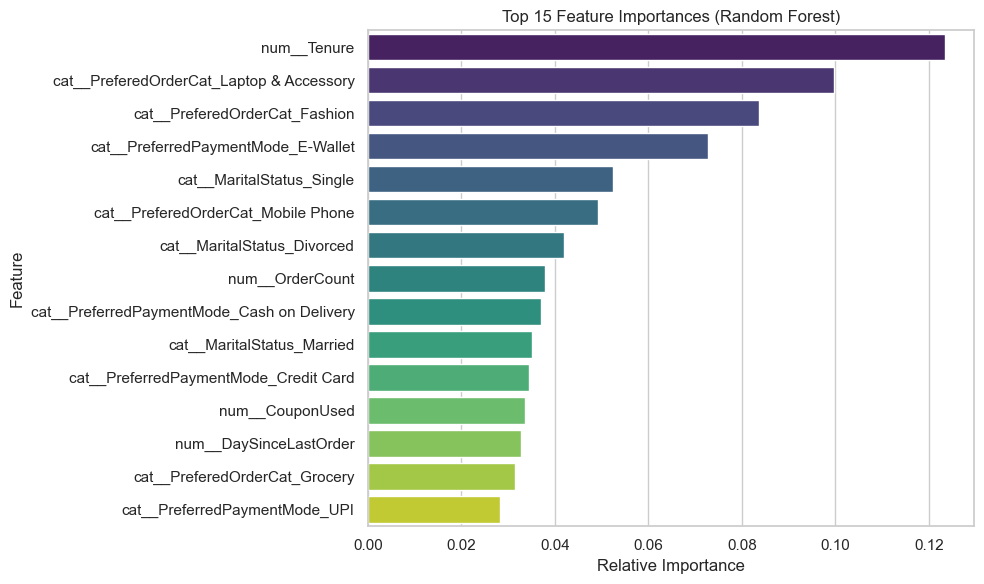

In [33]:
# DataFrame for feature importances
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

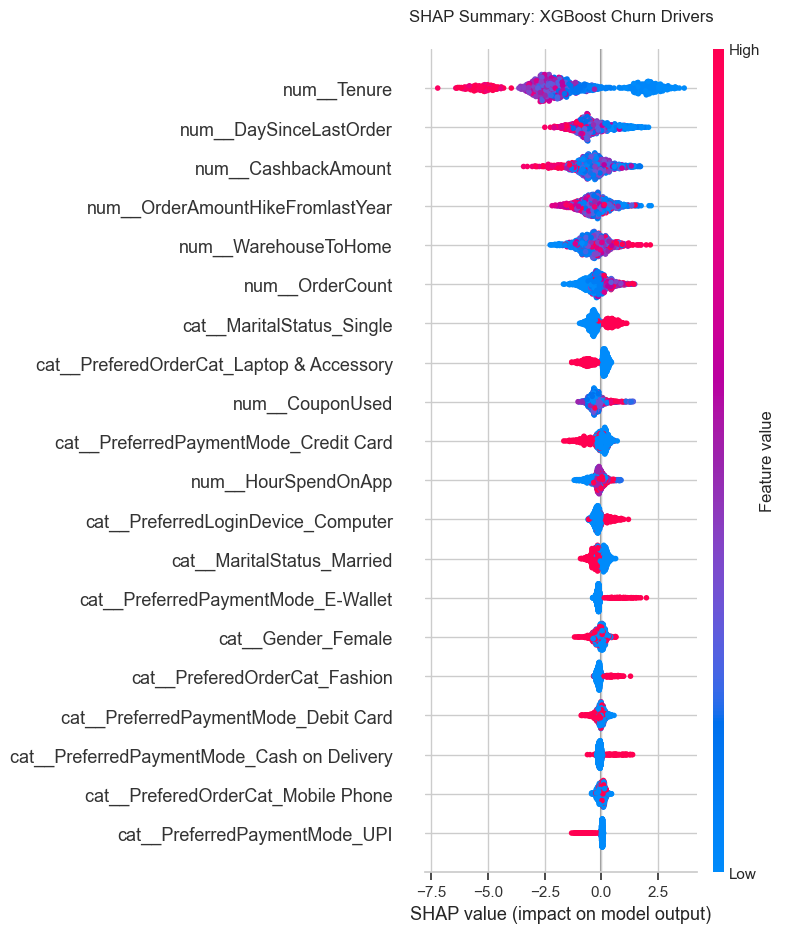

In [34]:
# Generate SHAP values (XGBoost is very fast with TreeExplainer)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Plot the summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title('SHAP Summary: XGBoost Churn Drivers', pad=20)
plt.tight_layout()
plt.show()

## Business Analysis

In [35]:
# 1. Load the raw data one more time just to rescue the CustomerIDs
original_raw_df = pd.read_csv('E_Commerce_Dataset.csv')

# 2. Create a new dataframe for business analysis by copying X_test
business_insights_df = X_test.copy()

# 3. Add the model's previously calculated predictions
business_insights_df['Predicted_Churn'] = y_pred
business_insights_df['Churn_Probability_Score'] = y_pred_probs

# 4. Bring back the CustomerID and RFM segment using the preserved index
business_insights_df['CustomerID'] = original_raw_df.loc[X_test.index, 'CustomerID']
business_insights_df['Customer_Segment'] = df.loc[X_test.index, 'Customer_Segment']

# 5. Filter for the high-value intervention list
high_value_churners = business_insights_df[
    (business_insights_df['Predicted_Churn'] == 1) & 
    (business_insights_df['Customer_Segment'].isin(['VIP', 'Loyal']))
]

# 6. Sort by the highest risk
high_value_churners = high_value_churners.sort_values(by='Churn_Probability_Score', ascending=False)

# 7. Reorganize the columns so CustomerID is the very first thing marketing sees
final_columns_to_show = ['CustomerID', 'Customer_Segment', 'Churn_Probability_Score', 'Tenure', 'CityTier', 'Gender']

print(f"Found {len(high_value_churners)} high-value customers at risk of churning!")
display(high_value_churners[final_columns_to_show].head(10))

Found 48 high-value customers at risk of churning!


,CustomerID,Customer_Segment,Churn_Probability_Score,Tenure,CityTier,Gender
2352,52353,Loyal,0.997421,0.0,1,Female
1037,51038,Loyal,0.993730,0.0,3,Male
2342,52343,Loyal,0.993253,0.0,1,Female
5346,55347,VIP,0.992989,1.0,3,Male
3486,53487,Loyal,0.991425,1.0,1,Male
4952,54953,VIP,0.989656,1.0,1,Female
4453,54454,Loyal,0.989583,1.0,3,Male
4912,54913,Loyal,0.989018,1.0,1,Female
3697,53698,VIP,0.988676,1.0,1,Female
568,50569,Loyal,0.988655,0.0,3,Male


In [36]:
high_value_churners[final_columns_to_show].to_csv("high_value_customers_at_risk.csv", index=False)